## Analysis of the obtained results

In [12]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [14]:
from analysis_tools import (
    load_and_merge_profiles
    )

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

=== Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive']




=== DEMOGRAPHIC ACCURACY DIFFERENCES ===

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 17
Significant Differences Found: 2
Statistical Significance Rate: 11.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_black                      Effect Size:  1.307 (Large)
 2. black_vs_white                      Effect Size: -1.030 (Large)
 3. intersectional_black_man_vs_woman   Effect Size: -0.769 (Medium)
 4. cognitive_balanced_vs_expansive     Effect Size: -0.750 (Medium)
 5. cognitive_balanced_vs_low_harm      Effect Size: -0.661 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.700 | Woman: 0.702
         Δ = -0.003 | p = 0.402 | d = -0.321
[SIGNIFICANT] asian_vs_black                      | Asian: 0.705 | Black: 0.695
         Δ = +0.010 | p = 0.013 | d = 1.307
[NON-SIGNIFICANT]     asian_vs_white           

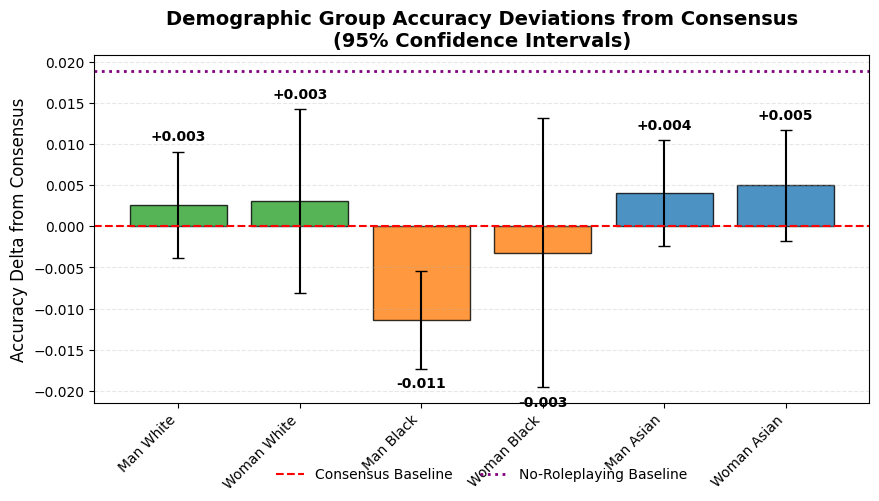

In [15]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df)


Running factorial ANOVA on profile traits...


FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT (man vs woman):
  man mean: 0.6997
  woman mean: 0.7024
  p-value: 0.4023 
  Cohen's d: 0.321
ETHNICITY MAIN EFFECT:
  white mean: 0.7034
  black mean: 0.6950
  asian mean: 0.7048
  F-statistic: 4.875
  p-value: 0.0156 ***
COGNITIVE_STYLE MAIN EFFECT:
  expansive mean: 0.7030
  literal mean: 0.7020
  high_harm mean: 0.7017
  low_harm mean: 0.7027
  balanced mean: 0.6960
  F-statistic: 0.649
  p-value: 0.6329 

INTERACTION EFFECTS (gender x ethnicity):
  man x white: 0.7032
  man x black: 0.6916
  man x asian: 0.7044
  woman x white: 0.7036
  woman x black: 0.6984
  woman x asian: 0.7052
  → OLS p-value for gender x ethnicity: 0.5918

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT (man vs woman):
  man mean: 0.0440
  woman mean: 0.0442
  p-value: 0.9800 
  Cohen's d: 0.010
ETHNICITY MAIN EFFECT:
  white mean: 0.0635
  black mean: 0.0293
  asian mean: 0.0394
  F-statistic: 8.852
  p-value: 0.001

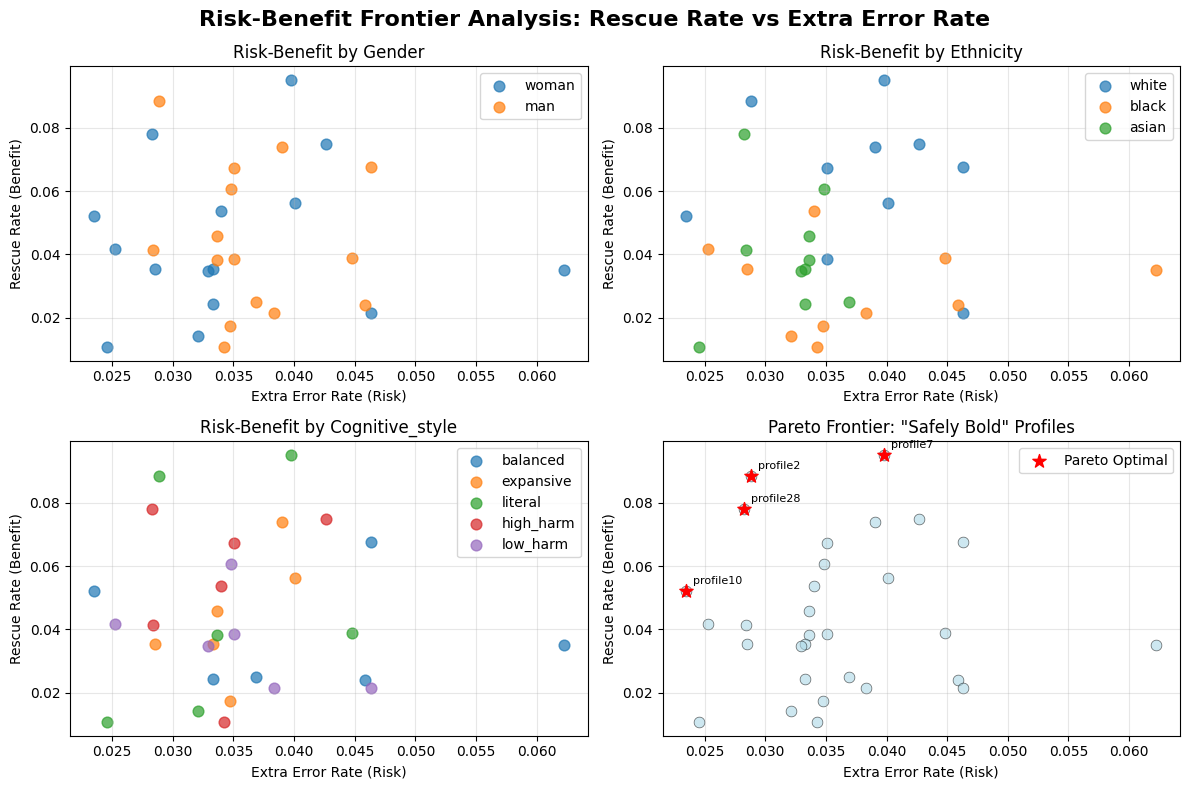


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile10_passive: gender: woman, ethnicity: white, cognitive_style: balanced
    Rescue Rate: 0.052, Extra Error Rate: 0.023
  profile28_passive: gender: woman, ethnicity: asian, cognitive_style: high_harm
    Rescue Rate: 0.078, Extra Error Rate: 0.028
  profile2_passive: gender: man, ethnicity: white, cognitive_style: literal
    Rescue Rate: 0.088, Extra Error Rate: 0.029
  profile7_passive: gender: woman, ethnicity: white, cognitive_style: literal
    Rescue Rate: 0.095, Extra Error Rate: 0.040

Risk-Benefit Statistics:
  Average rescue rate: 0.044
  Average extra error rate: 0.036
  Best rescue rate: 0.095
  Lowest extra error rate: 0.023

Profile Archetypes:
  Safest Profile: profile10_passive (gender: woman, ethnicity: white, cognitive_style: balanced)
    Extra Error Rate: 0.023
  Most Beneficial Profile: profile7_passive (gender: woman, ethnicity: white, cognitive_style: literal)
    Rescue Rate: 0.095

Runni

In [16]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df)

🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

=== Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--------------------------------------------------
man white expansive      : 0.7020 (-0.0180) | Rescue: 0.064 | Extra Err: 0.050 | n=1
man white literal        : 0.7100 (-0.0100) | Rescue: 0.071 | Extra Err: 0.042 | n=1
man white high_harm      : 0.7060 (-0.0140) | Rescue: 0.064 | Extra Err: 0.044 | n=1
man white low_harm       : 0.7020 (-0.0180) | Rescue: 0.050 | Extra Err: 0.044 | n=1
man white balanced       : 0.6960 (-0.0240) | Rescue: 0.057 | Extra Err: 0.056 | n=1
woman white expansive    : 0.7020 (-0.0180) | Rescue: 0.071 | Extra Err: 0.053 | n=1
woman white literal      : 0.7080 (-0.0120) | Rescue: 0.093 | Extra Err: 0.053 | n=1
woman white high_harm    : 0.7000 (-0.0200) | Rescue: 0.071 | Extra Err: 0.056 | n=1
woman white low_harm     : 0.6920 (-0.0280) | Rescue: 0.043 | Extra Err: 0.056 | n=1
woman white b

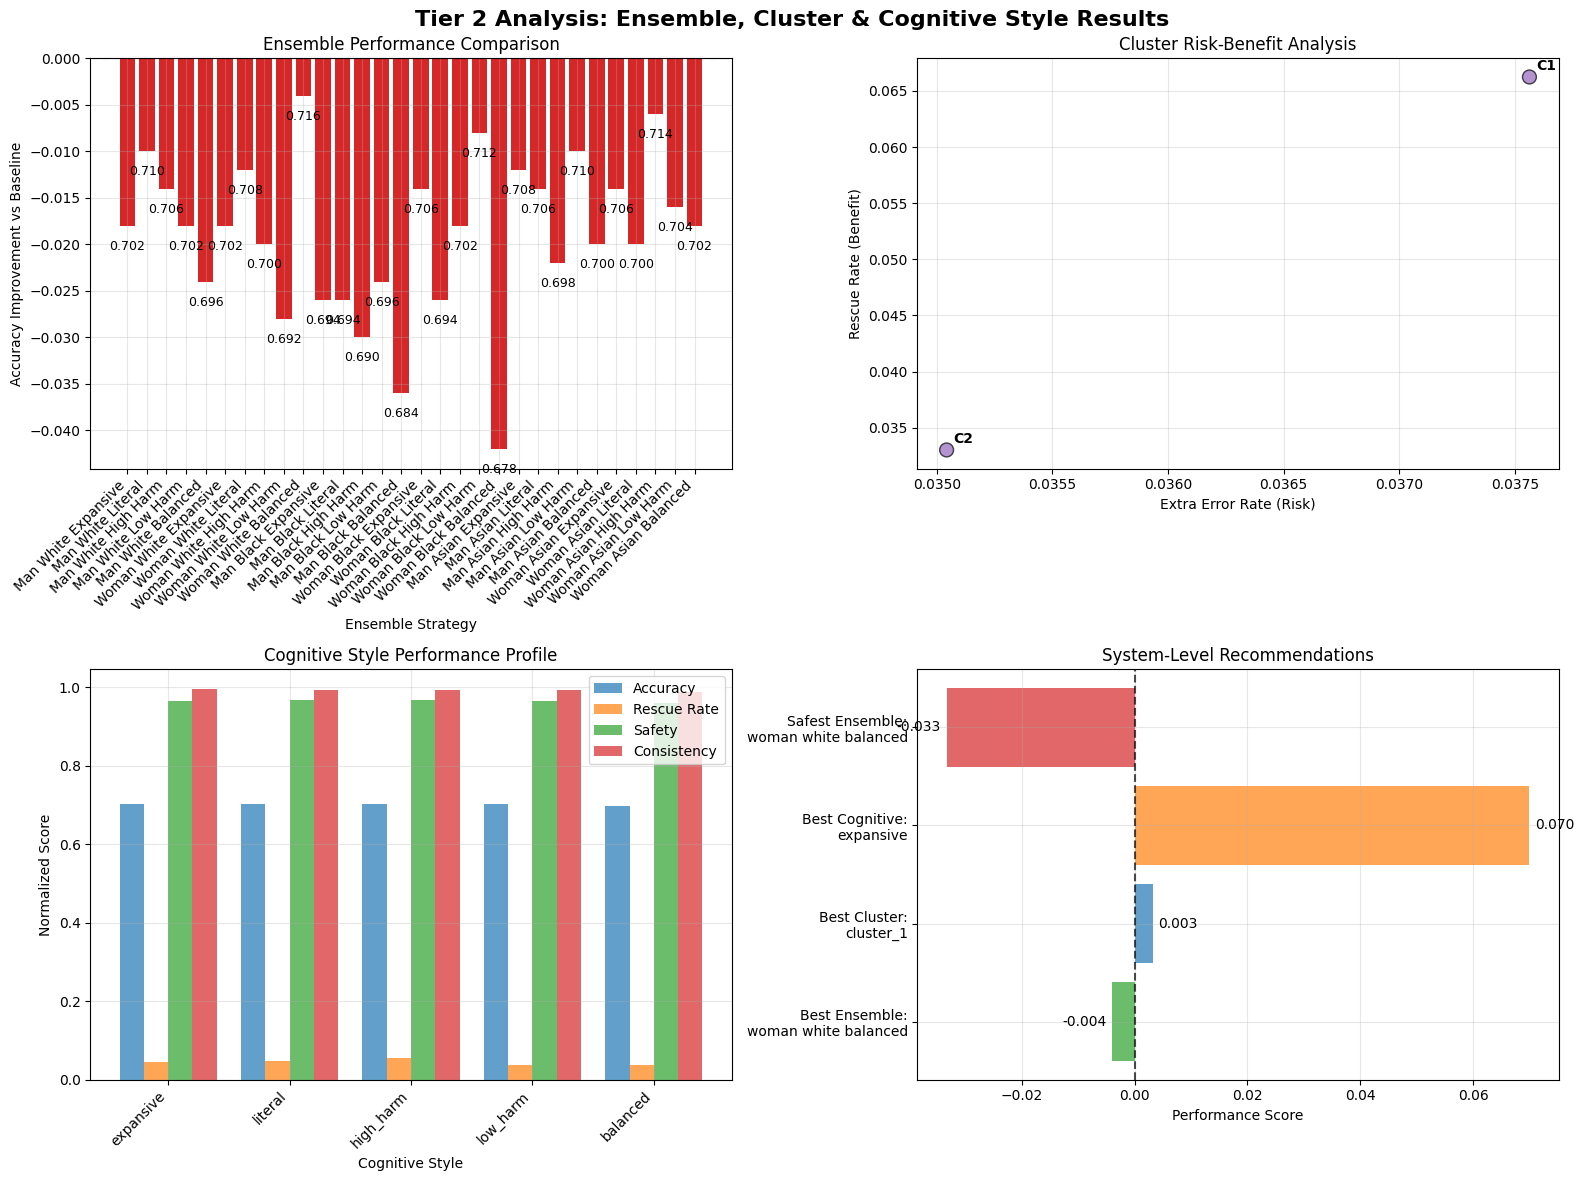


TIER 2 EXECUTIVE SUMMARY

=== KEY FINDINGS:
   • Best Ensemble Strategy: woman white balanced
   • Best Cluster: cluster_1
   • Best Cognitive Style: expansive

=== PERFORMANCE GAINS:
   • Best Ensemble Improvement: +-0.0040
   • Safety-Performance Balance Achieved

=== SAFETY INSIGHTS:
   • Safest Strategy: woman white balanced
   • Minimum Extra Error Rate: 0.033


In [17]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.125, p=0.5100 
  Volatility vs Rescue Rate: r=-0.154, p=0.4158 
  Boldness vs Accuracy: r=0.381, p=0.0377 ***

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Stable Bold – Best performance, low risk
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Stable Bold – Best performance, low risk
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Volatile Bold – High risk, high moral value
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Volatile Cautious – High risk, low moral value
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Vola

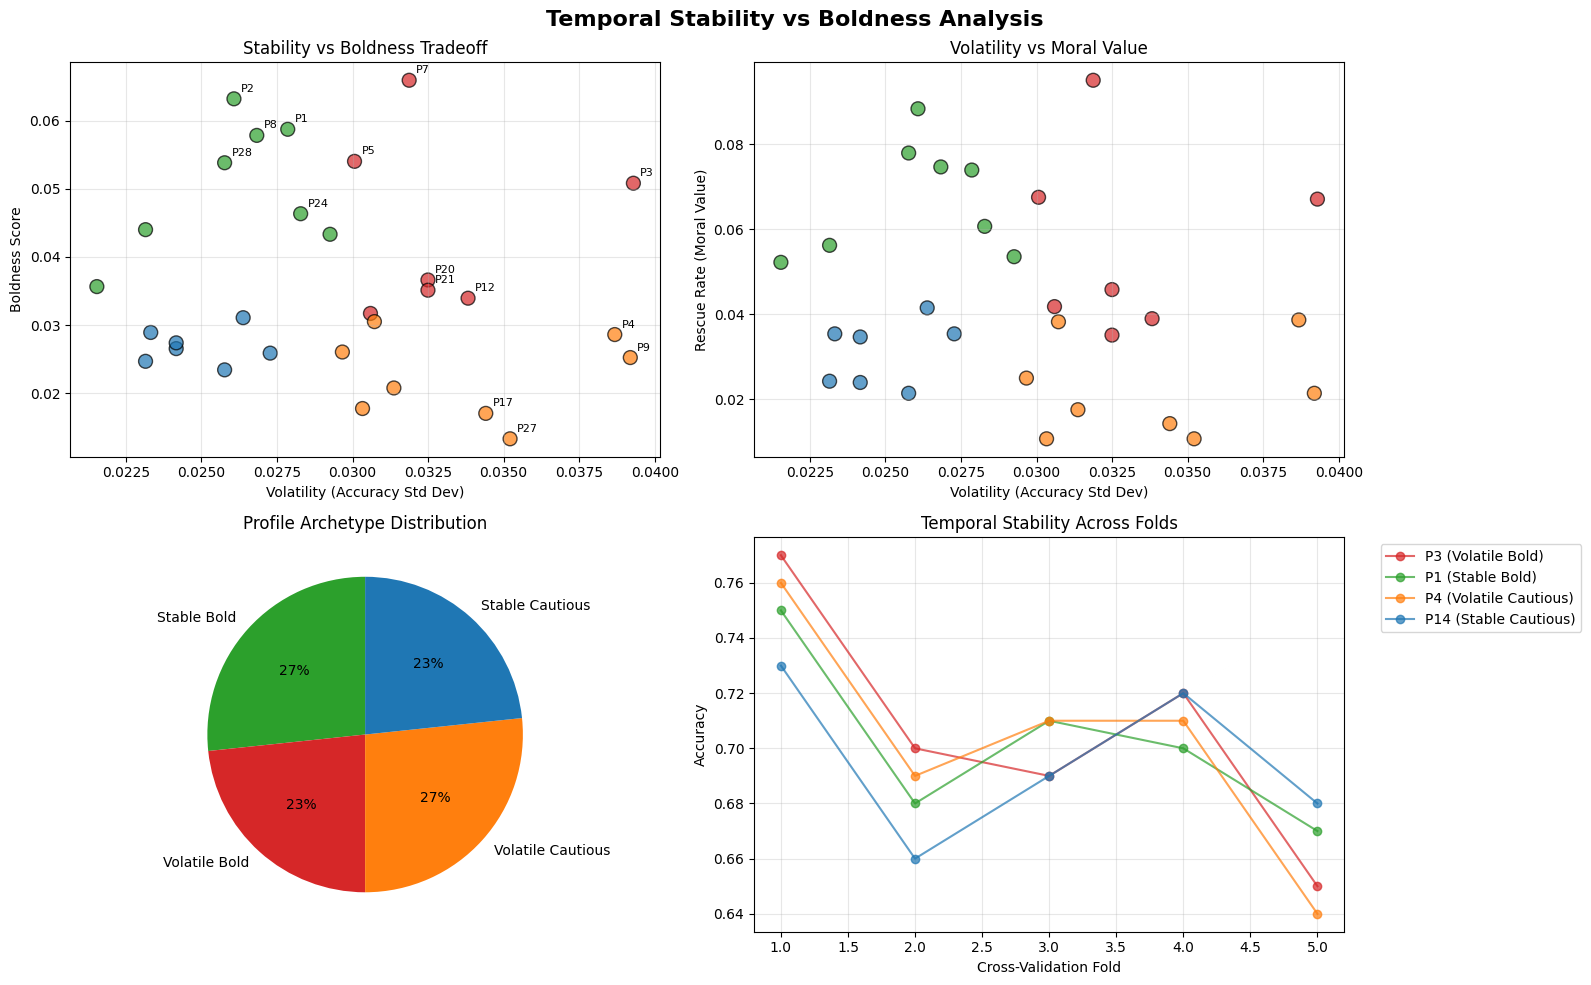


 === Creating Causal Model Visualizations... ===


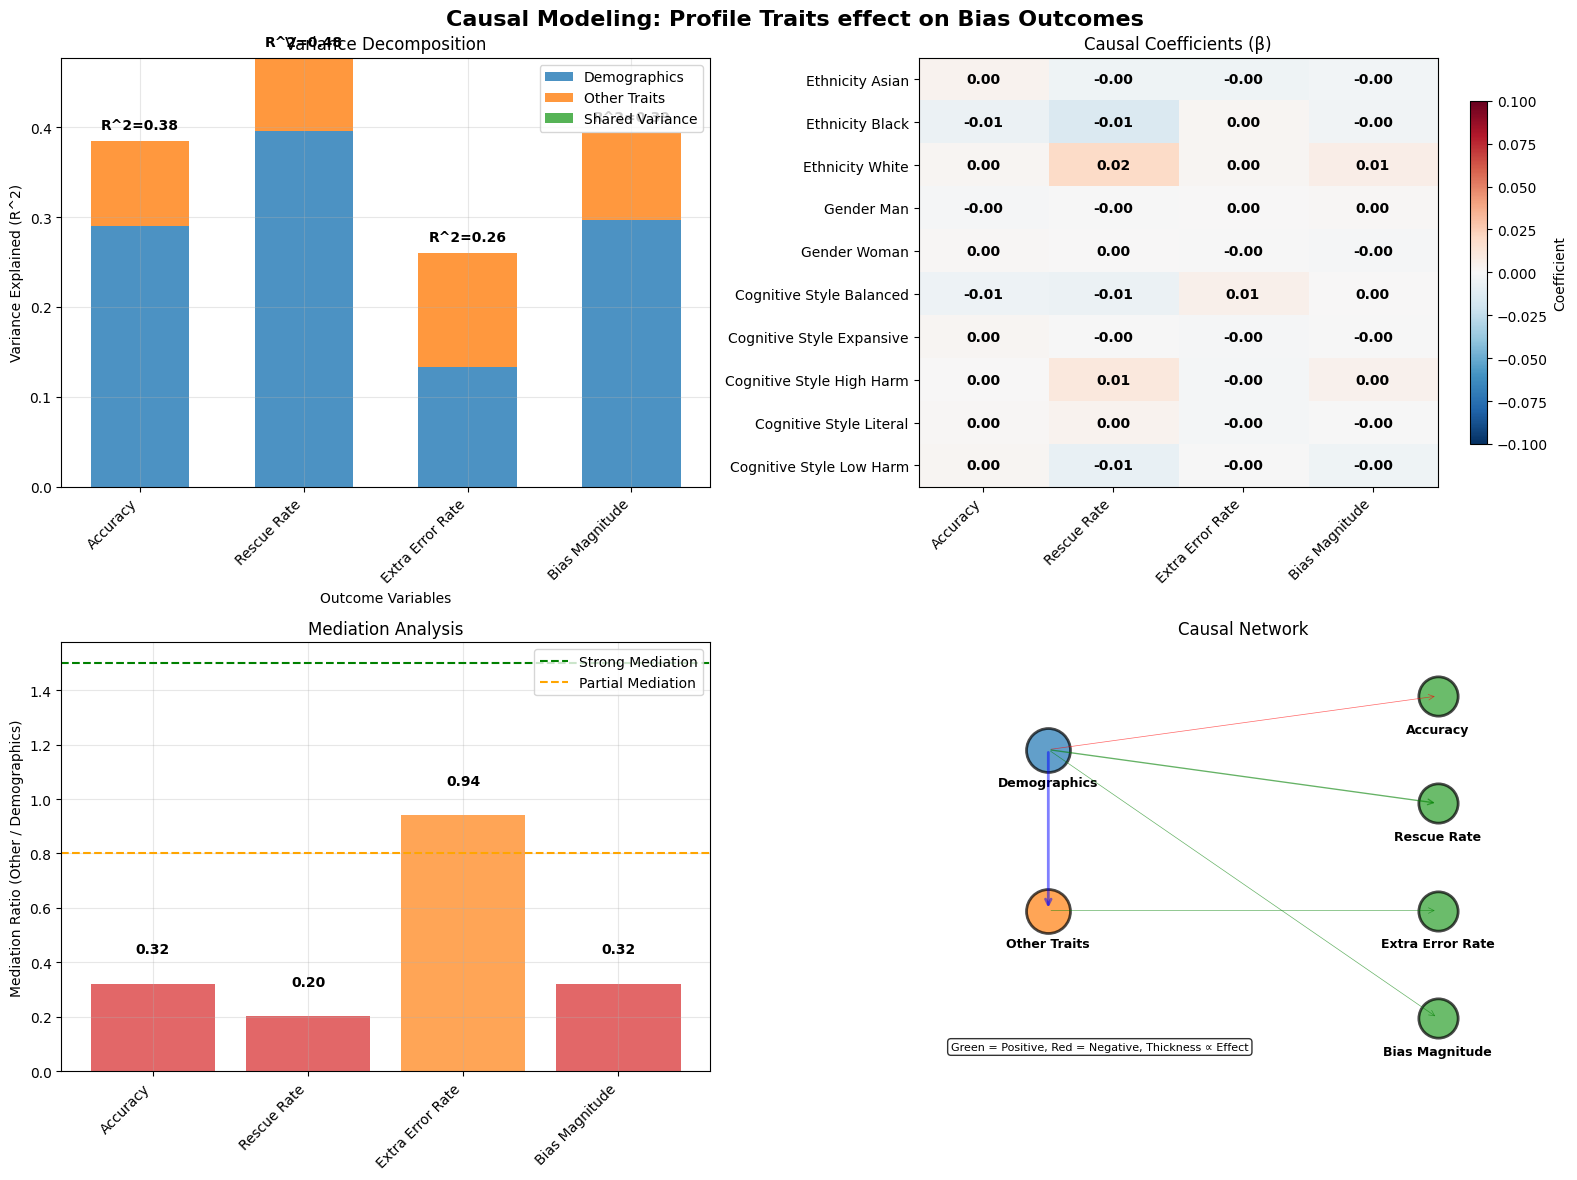


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Stable profiles outperform volatile ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): ethnicity_black
   - Mediation effects found: extra_error_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 4/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: ethnicity_white is the most critical trait for system design
   Evidence: Appears in 2/3 optimization objectives
   Implication: Systems should prioritize profiles with ethnicity_white characteristics


In [22]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Analysis of Few-shots role playing

In [23]:
from analysis_tools import (
    load_and_merge_profiles
    )
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

=== Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive']




=== DEMOGRAPHIC ACCURACY DIFFERENCES ===

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 17
Significant Differences Found: 1
Statistical Significance Rate: 5.9%

LARGEST EFFECT SIZES
----------------------------------------
 1. asian_vs_black                      Effect Size:  1.047 (Large)
 2. cognitive_high_harm_vs_low_harm     Effect Size:  1.006 (Large)
 3. intersectional_asian_man_vs_woman   Effect Size: -0.834 (Large)
 4. cognitive_high_harm_vs_literal      Effect Size:  0.825 (Large)
 5. cognitive_balanced_vs_low_harm      Effect Size:  0.543 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.705 | Woman: 0.707
         Δ = -0.002 | p = 0.565 | d = -0.220
[SIGNIFICANT] asian_vs_black                      | Asian: 0.709 | Black: 0.702
         Δ = +0.007 | p = 0.039 | d = 1.047
[NON-SIGNIFICANT]     asian_vs_white              

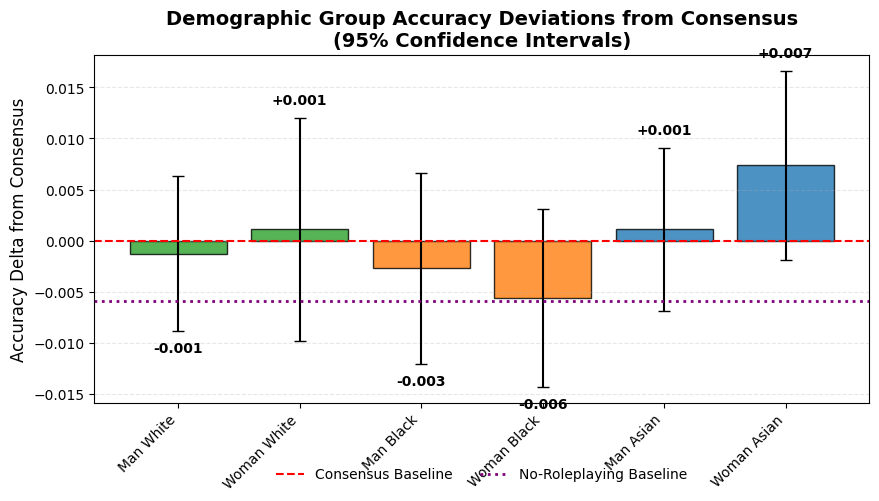

In [24]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df)


Running factorial ANOVA on profile traits...


FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT (man vs woman):
  man mean: 0.7051
  woman mean: 0.7067
  p-value: 0.5654 
  Cohen's d: 0.220
ETHNICITY MAIN EFFECT:
  white mean: 0.7058
  black mean: 0.7024
  asian mean: 0.7094
  F-statistic: 2.428
  p-value: 0.1072 
COGNITIVE_STYLE MAIN EFFECT:
  expansive mean: 0.7060
  literal mean: 0.7040
  high_harm mean: 0.7093
  low_harm mean: 0.7030
  balanced mean: 0.7070
  F-statistic: 0.644
  p-value: 0.6363 

INTERACTION EFFECTS (gender x ethnicity):
  man x white: 0.7048
  man x black: 0.7036
  man x asian: 0.7068
  woman x white: 0.7068
  woman x black: 0.7012
  woman x asian: 0.7120
  → OLS p-value for gender x ethnicity: 0.5124

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT (man vs woman):
  man mean: 0.0544
  woman mean: 0.0570
  p-value: 0.6808 
  Cohen's d: 0.157
ETHNICITY MAIN EFFECT:
  white mean: 0.0586
  black mean: 0.0495
  asian mean: 0.0591
  F-statistic: 1.004
  p-value: 0.3798 


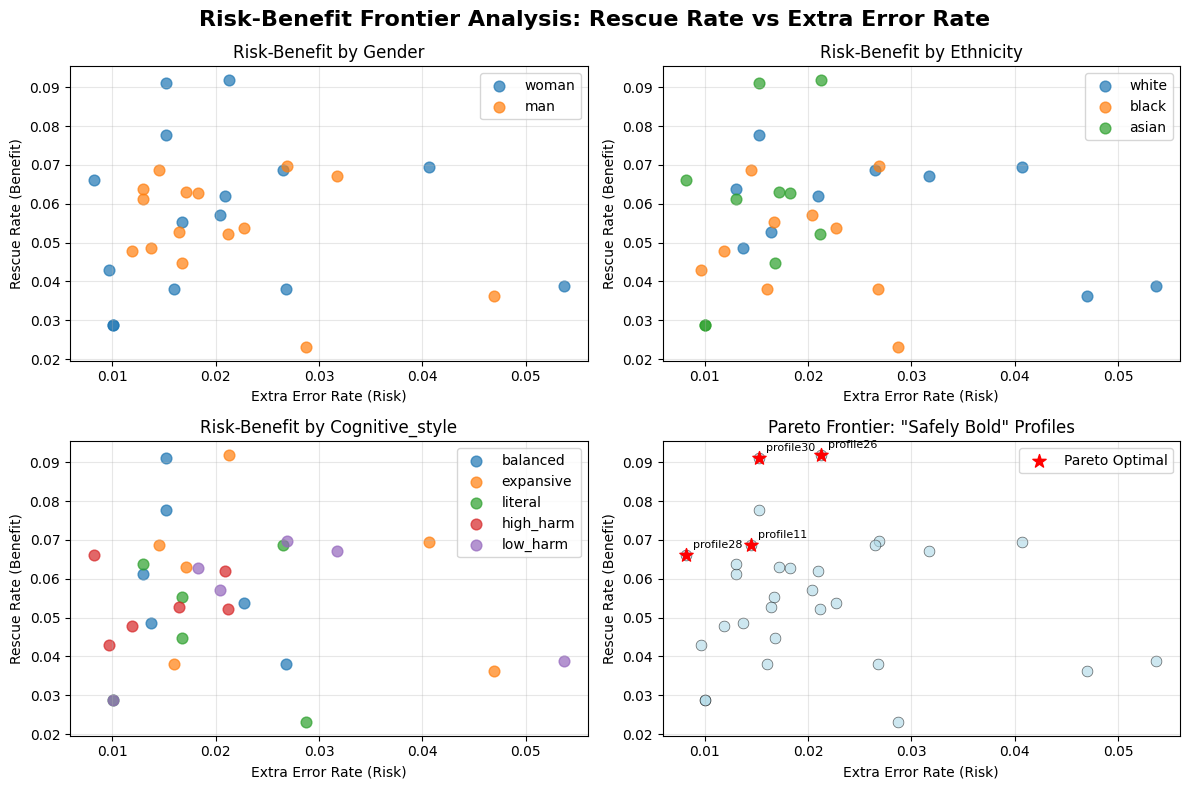


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile11_passive: gender: man, ethnicity: black, cognitive_style: expansive
    Rescue Rate: 0.069, Extra Error Rate: 0.014
  profile26_passive: gender: woman, ethnicity: asian, cognitive_style: expansive
    Rescue Rate: 0.092, Extra Error Rate: 0.021
  profile28_passive: gender: woman, ethnicity: asian, cognitive_style: high_harm
    Rescue Rate: 0.066, Extra Error Rate: 0.008
  profile30_passive: gender: woman, ethnicity: asian, cognitive_style: balanced
    Rescue Rate: 0.091, Extra Error Rate: 0.015

Risk-Benefit Statistics:
  Average rescue rate: 0.056
  Average extra error rate: 0.021
  Best rescue rate: 0.092
  Lowest extra error rate: 0.008

Profile Archetypes:
  Safest Profile: profile28_passive (gender: woman, ethnicity: asian, cognitive_style: high_harm)
    Extra Error Rate: 0.008
  Most Beneficial Profile: profile26_passive (gender: woman, ethnicity: asian, cognitive_style: expansive)
    Rescue Rate: 0.

In [25]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df)

🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

=== Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS
Baseline accuracy: 0.7000

Ensemble Performance by Trait Group:
--------------------------------------------------
man white expansive      : 0.6960 (-0.0040) | Rescue: 0.060 | Extra Err: 0.031 | n=1
man white literal        : 0.7060 (+0.0060) | Rescue: 0.073 | Extra Err: 0.023 | n=1
man white high_harm      : 0.7120 (+0.0120) | Rescue: 0.087 | Extra Err: 0.020 | n=1
man white low_harm       : 0.7020 (+0.0020) | Rescue: 0.093 | Extra Err: 0.037 | n=1
man white balanced       : 0.7080 (+0.0080) | Rescue: 0.080 | Extra Err: 0.023 | n=1
woman white expansive    : 0.7020 (+0.0020) | Rescue: 0.107 | Extra Err: 0.043 | n=1
woman white literal      : 0.7100 (+0.0100) | Rescue: 0.100 | Extra Err: 0.029 | n=1
woman white high_harm    : 0.7120 (+0.0120) | Rescue: 0.080 | Extra Err: 0.017 | n=1
woman white low_harm     : 0.6940 (-0.0060) | Rescue: 0.060 | Extra Err: 0.034 | n=1
woman white b

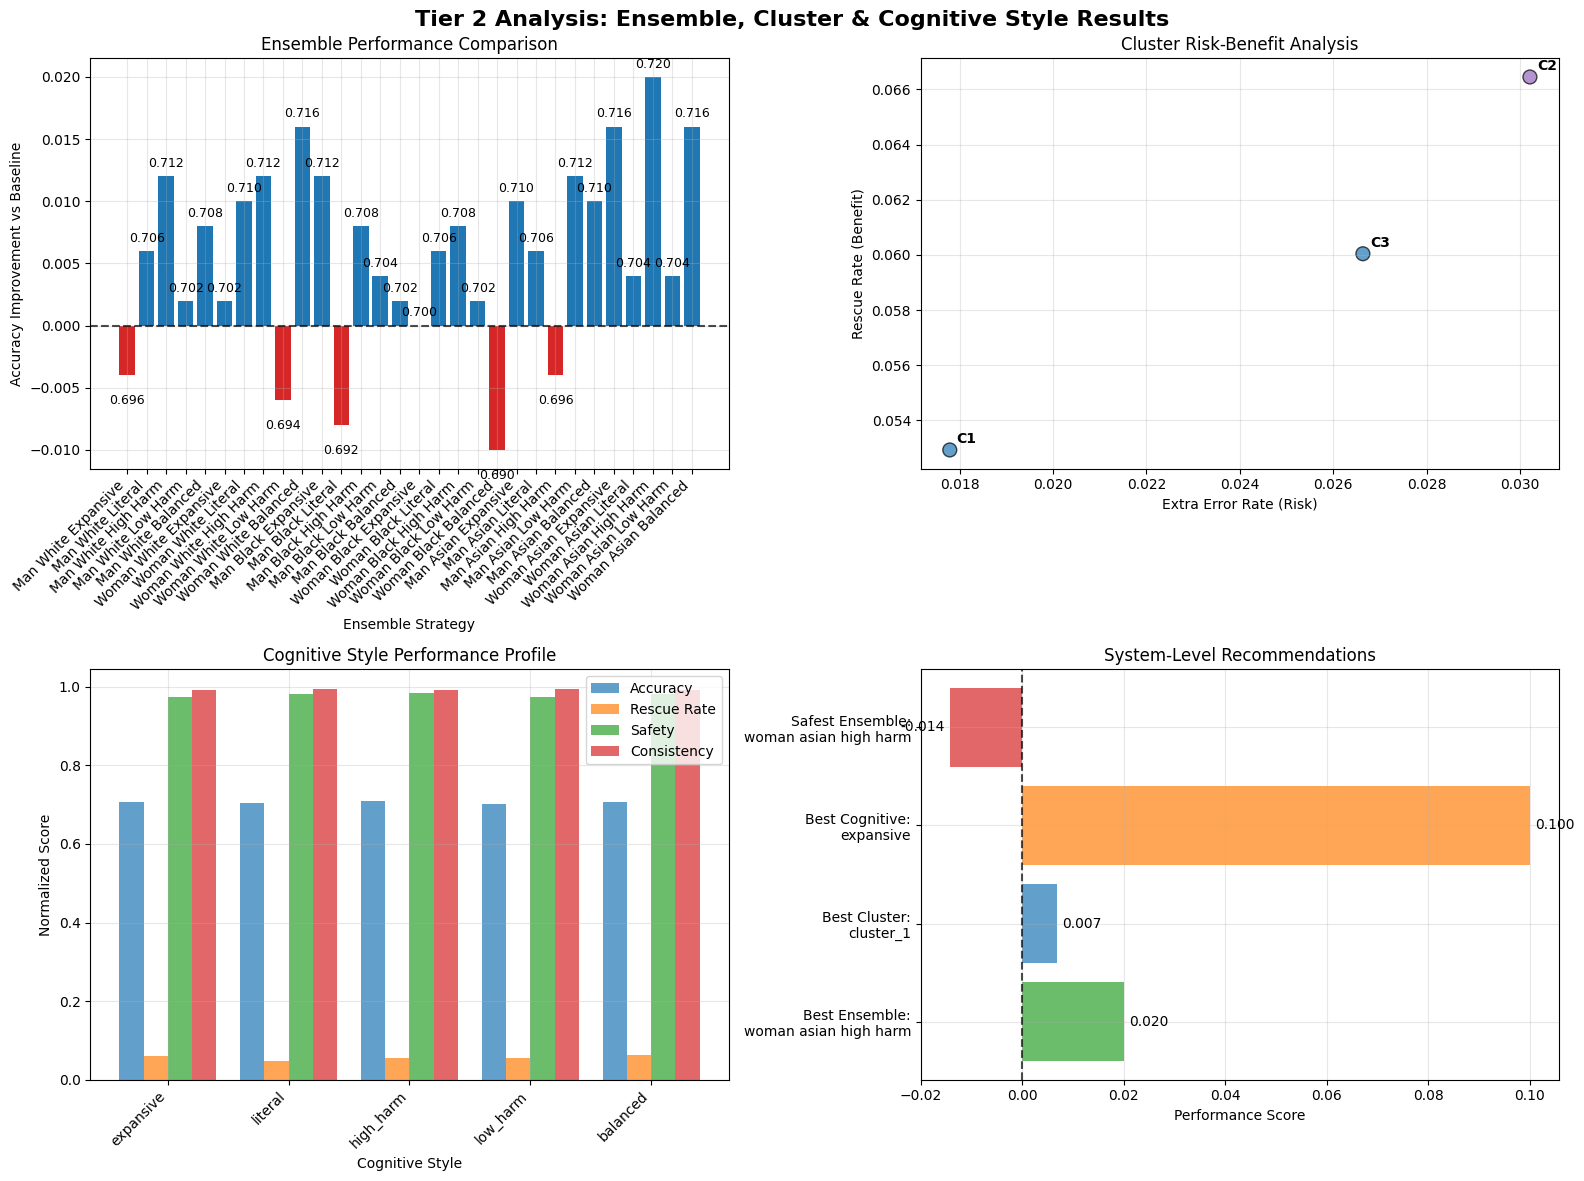


TIER 2 EXECUTIVE SUMMARY

=== KEY FINDINGS:
   • Best Ensemble Strategy: woman asian high_harm
   • Best Cluster: cluster_1
   • Best Cognitive Style: expansive

=== PERFORMANCE GAINS:
   • Best Ensemble Improvement: +0.0200
   • Safety-Performance Balance Achieved

=== SAFETY INSIGHTS:
   • Safest Strategy: woman asian high_harm
   • Minimum Extra Error Rate: 0.014


In [26]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.252, p=0.1799 
  Volatility vs Rescue Rate: r=-0.142, p=0.4552 
  Boldness vs Accuracy: r=0.424, p=0.0196 ***

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Volatile Cautious – High risk, low moral value
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Volatile Bold – High risk, high moral value
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Stable Cautious – Low risk, predictable
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Stable Bold – Best performance, low risk
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Volat

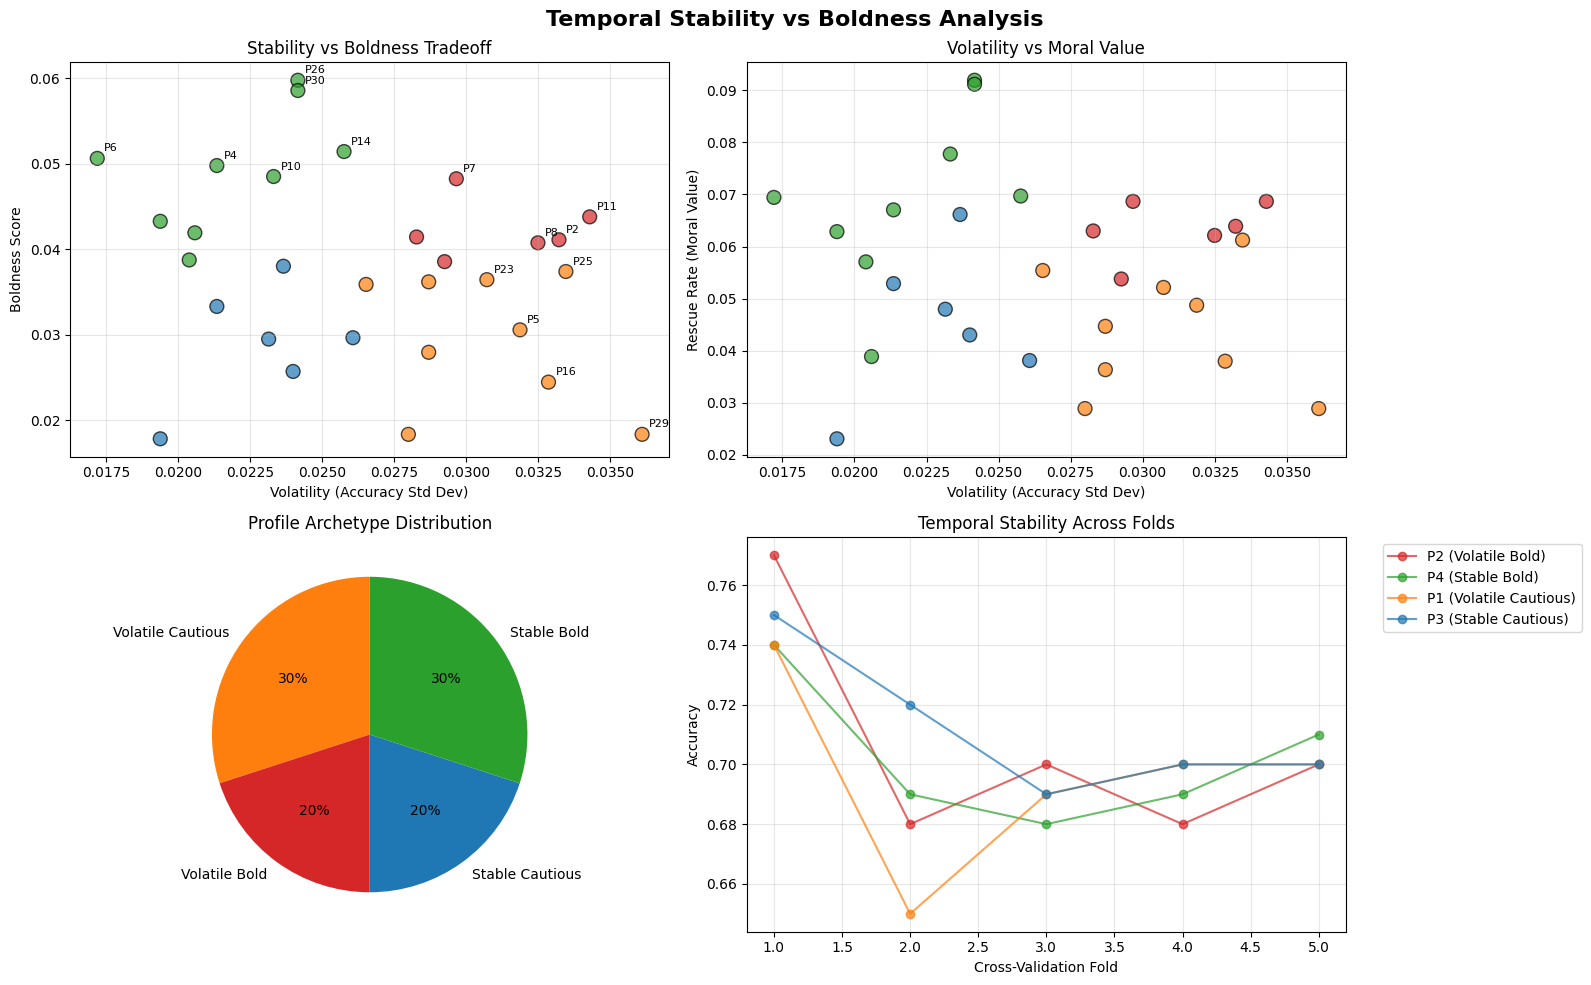


 === Creating Causal Model Visualizations... ===


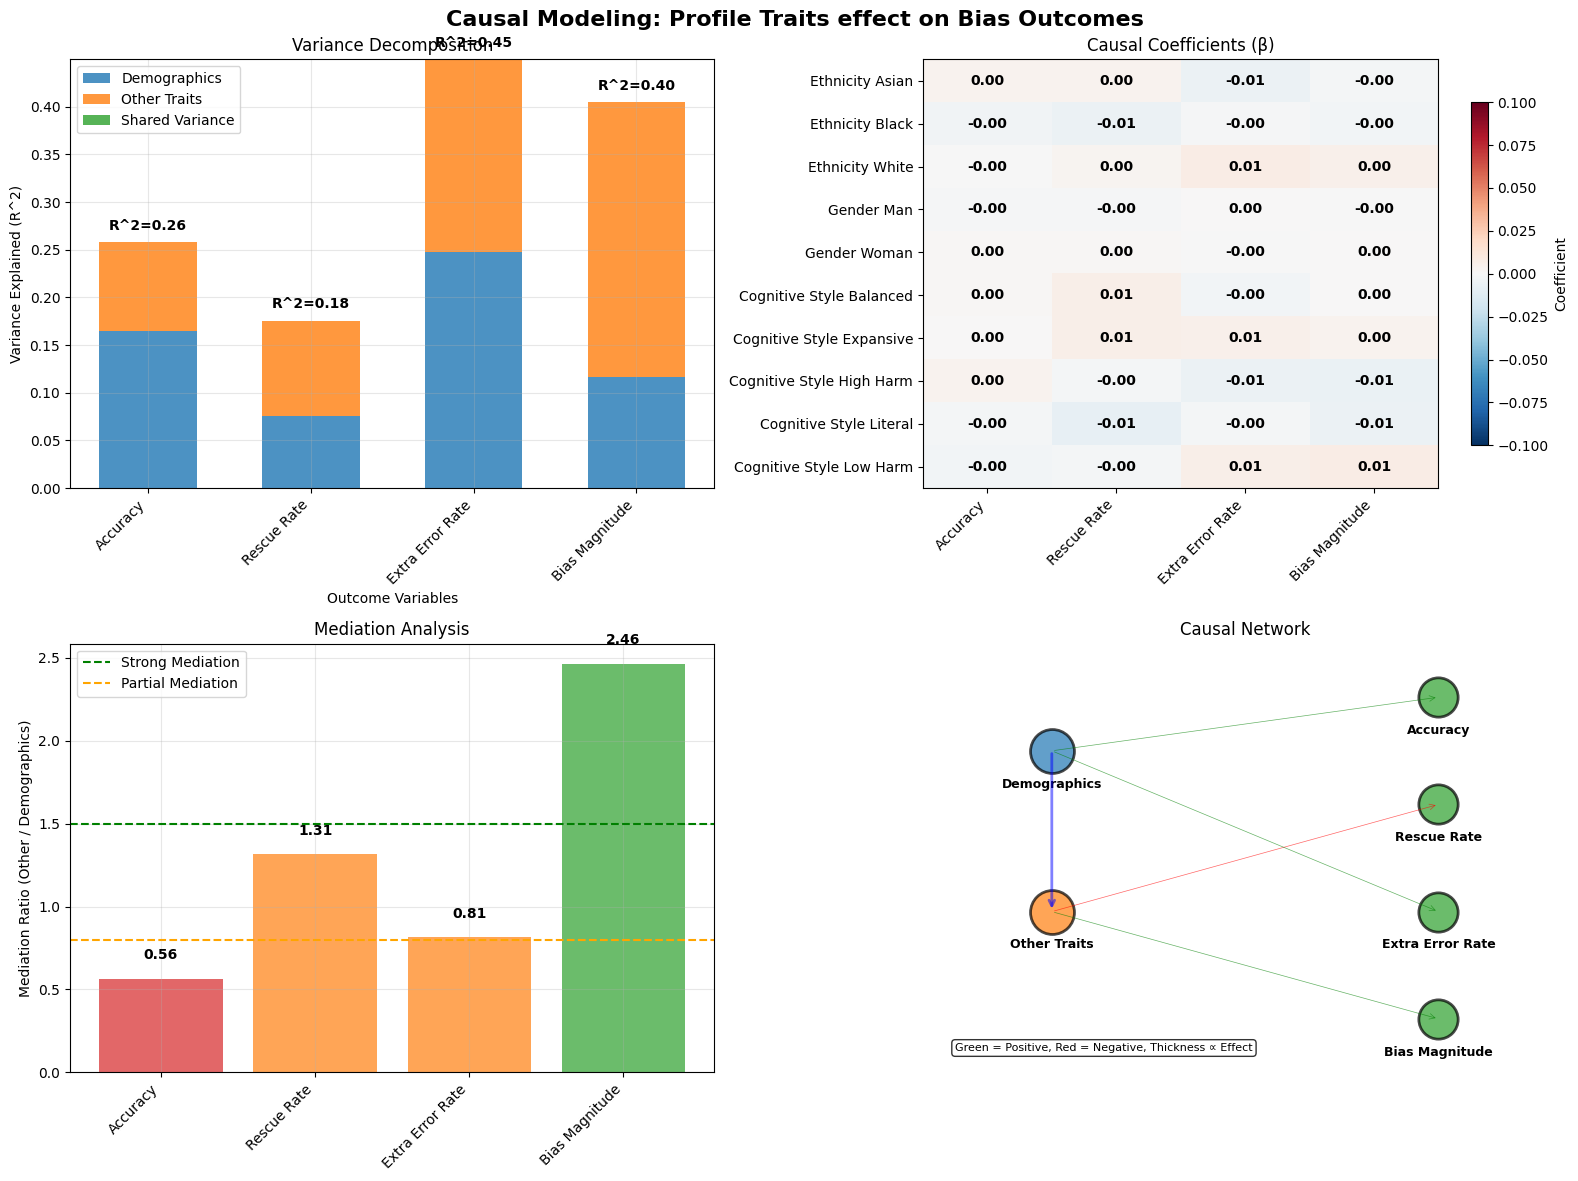


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Stable profiles outperform volatile ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Strongest predictor of moral value (rescue): cognitive_style_literal
   - Strongest predictor of performance (accuracy): ethnicity_asian
   - Mediation effects found: rescue_rate: Partial mediation, extra_error_rate: Partial mediation, bias_magnitude: Strong other traits mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 2/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: cognitive_style_balanced is the most critical trait for system design
   Evidence: Appears in 3/3 optimization objectives
   Implication: Systems should prioritize profiles with cognitive_style_balanced characteristics


In [27]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Manipulation detection

In [ ]:
merged_manipulation = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    extra_cols=["technique", "vulnerability"]
)
merged_manipulation["task"] = "manipulation"

=== Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1_passive', 'profile1_active', 'profile2_passive', 'profile2_active', 'profile3_passive', 'profile3_active', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive']


NameError: name 'evaluate_role_playing_effects' is not defined